
## 1. Цель исследования

**Задача:**  
Оценить влияние индивидуальных и страновых факторов на зависимую переменную (Y),  
учитывая иерархическую структуру данных (индивиды вложены в страны).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ESS1e06_7.csv', low_memory=False)
df

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,inwdd,inwmm,inwyr,inwshh,inwsmm,inwemm,inwehh,inwtm,spltadm,supqadm
0,ESS1e06_7,1,6.7,23.11.2023,1,AT,0.9452,0.940933,0.271487,0.255451,...,23.0,3.0,2003,13,30,20,14,50.0,10.0,1.0
1,ESS1e06_7,1,6.7,23.11.2023,2,AT,0.4726,0.470466,0.271487,0.127726,...,29.0,3.0,2003,14,0,0,15,60.0,9.0,1.0
2,ESS1e06_7,1,6.7,23.11.2023,3,AT,0.9452,1.392155,0.271487,0.377953,...,31.0,3.0,2003,18,0,10,19,70.0,10.0,1.0
3,ESS1e06_7,1,6.7,23.11.2023,4,AT,0.9452,1.382163,0.271487,0.375240,...,3.0,4.0,2003,11,55,0,13,65.0,9.0,1.0
4,ESS1e06_7,1,6.7,23.11.2023,6,AT,1.8905,1.437766,0.271487,0.390336,...,1.0,4.0,2003,12,55,55,13,60.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42354,ESS1e06_7,1,6.7,23.11.2023,1810,SI,1.0000,1.249730,0.109537,0.136892,...,20.0,11.0,2002,17,15,45,18,90.0,12.0,1.0
42355,ESS1e06_7,1,6.7,23.11.2023,1811,SI,1.0000,1.049310,0.109537,0.114938,...,23.0,11.0,2002,16,30,10,18,100.0,13.0,1.0
42356,ESS1e06_7,1,6.7,23.11.2023,1812,SI,1.0000,1.103449,0.109537,0.120869,...,21.0,11.0,2002,17,0,20,18,80.0,13.0,1.0
42357,ESS1e06_7,1,6.7,23.11.2023,1813,SI,1.0000,1.186905,0.109537,0.130010,...,18.0,11.0,2002,17,5,10,18,65.0,15.0,1.0


Вычислим размер получившегося датасета.

In [ ]:
print(f'Количество строк: {df.shape[0]} \nКоличество столбцов: {df.shape[1]}')

Количество строк: 42359 
Количество столбцов: 567


Ряд переменных являются техническими и не будут иметь какую-либо ценность при построении модели:
* name - Название файла данных (ESS1e06_7)
* edition - Версия набора данных
* preddate - Дата выпуска файла
* idno - Уникальный номер респондента
* psu - Primary Sampling Unit (первичная единица выборки)
* stratum - Стратификационная переменная
* prob - Вероятность включения в выборку
* inwdd, inwmm, inwyr - Дата интервью
* inwshh, inwsmm, inwemm, inwehh, inwtm - Время начала и конца интервью.

In [ ]:
technical_vars = [
    "name", "edition", "proddate", "idno",
    "psu", "stratum", "prob",
    "inwdd", "inwmm", "inwyr",
    "inwshh", "inwsmm", "inwemm", "inwehh", "inwtm"]

df = df.drop(columns=[x for x in technical_vars if x in df.columns])

Признаки из датасета закодированы таким образом, что значения "Отказ", "Не знаю", "Нет ответа" как числа в формате "ХХХХ", "ХХХ", "ХХ"б "Х", поэтому предобработаем датасет в четыре шага:
1. Переведем сначала признаки со значениями ХХХХ.
2. Далее ХХХ.
3. После ХХ.
4. Последним шагом переведем признаки Х.

In [ ]:
codes_1 = {9999, 8888, 7777}
codes_2 = {999, 888, 777, 666}
codes_3 = {99, 88, 77, 66}
codes_4 = {9, 8, 7}
changed_step1 = set()
changed_step2 = set()
changed_step3 = set()
for col in df.columns:
    s = df[col]

    # шаг 1
    if s.isin(codes_1).any():
        df.loc[s.isin(codes_1), col] = np.nan
        changed_step1.add(col)
        continue

    # шаг 2
    if s.isin(codes_2).any():
        df.loc[s.isin(codes_2), col] = np.nan
        changed_step2.add(col)
        continue

    # шаг 3
    if s.isin(codes_3).any():
        df.loc[s.isin(codes_3), col] = np.nan
        changed_step3.add(col)
        continue

    # шаг 4
    if s.isin(codes_4).any():
        df.loc[s.isin(codes_4), col] = np.nan

In [ ]:
df

,essround,cntry,dweight,pspwght,pweight,anweight,tvtot,tvpol,rdtot,rdpol,...,ipstrgv,ipadvnt,ipbhprp,iprspot,iplylfr,impenv,imptrad,impfun,spltadm,supqadm
0,1,AT,0.9452,0.940933,0.271487,0.255451,1.0,1.0,1.0,1.0,...,2.0,3.0,4.0,4.0,2.0,2.0,1.0,1.0,10.0,1.0
1,1,AT,0.4726,0.470466,0.271487,0.127726,3.0,2.0,4.0,1.0,...,3.0,1.0,4.0,4.0,3.0,1.0,6.0,3.0,9.0,1.0
2,1,AT,0.9452,1.392155,0.271487,0.377953,7.0,3.0,0.0,NaN,...,2.0,4.0,2.0,3.0,2.0,2.0,2.0,5.0,10.0,1.0
3,1,AT,0.9452,1.382163,0.271487,0.375240,1.0,1.0,1.0,1.0,...,3.0,6.0,2.0,4.0,2.0,1.0,5.0,5.0,9.0,1.0
4,1,AT,1.8905,1.437766,0.271487,0.390336,0.0,NaN,1.0,1.0,...,4.0,4.0,6.0,5.0,1.0,1.0,3.0,2.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42354,1,SI,1.0000,1.249730,0.109537,0.136892,1.0,1.0,0.0,NaN,...,2.0,5.0,3.0,3.0,4.0,2.0,5.0,4.0,12.0,1.0
42355,1,SI,1.0000,1.049310,0.109537,0.114938,3.0,3.0,2.0,2.0,...,2.0,6.0,3.0,5.0,5.0,2.0,2.0,5.0,13.0,1.0
42356,1,SI,1.0000,1.103449,0.109537,0.120869,7.0,2.0,0.0,NaN,...,2.0,3.0,3.0,5.0,3.0,2.0,5.0,3.0,13.0,1.0
42357,1,SI,1.0000,1.186905,0.109537,0.130010,2.0,2.0,2.0,2.0,...,1.0,6.0,1.0,3.0,2.0,1.0,1.0,2.0,15.0,1.0


Преобразование специальных кодов прошло успешно: служебные значения, обозначающие отказ, отсутствие ответа или неопределенность, были заменены на NaN. Это позволяет далее работать с пропусками стандартными средствами pandas и scikit-learn, не смешивая их с реальными значениями признаков.

545 признаков для анализа будут не нужны, поскольку это слишком много, для бóльшей проработки необходимо их сократить, оставив только несколько "Блоков признаков".
1. Оставляем базовые человеческие потребности, которые являются основой "Модели Шварца", на базе которой проводятся все современные социальные опросы. К данным признакам относятся: отношение к новизне (impdiff, ipadvnt, ipcrtiv, impfree), соблюдение традиций и общественного порядка (imptrad, ipbhprp, impsafe, ipstrgv), определяемый статус (imprich, ipsuces, ipshabt) и удовольствие (impfun).
2. Второй группой будут признаки отражающие социальное доверие (ppltrst, pplfair, pplhlp).
3. И наконец, последняя группа - количество потребляемой информации через ТВ и медиа (tvtot, rdtot, nwsptot, netuse).
Создадим итоговый датафрейм для дальнейшего анализа.

In [ ]:
value_vars = [
    'impdiff','impfree','ipadvnt','ipcrtiv',
    'imptrad','ipbhprp','impsafe','ipstrgv',
    'ipeqopt','iphlppl','ipudrst','iplylfr',
    'imprich','ipsuces','ipshabt', 'impfun']

trust_vars = ['ppltrst', 'pplfair', 'pplhlp']

tv_media_vars = ['tvtot', 'rdtot', 'nwsptot', 'netuse']
df_model = df[['cntry'] + value_vars + trust_vars + tv_media_vars]
df_model

,cntry,impdiff,impfree,ipadvnt,ipcrtiv,imptrad,ipbhprp,impsafe,ipstrgv,ipeqopt,...,ipsuces,ipshabt,impfun,ppltrst,pplfair,pplhlp,tvtot,rdtot,nwsptot,netuse
0,AT,3.0,1.0,3.0,2.0,1.0,4.0,2.0,2.0,1.0,...,3.0,3.0,1.0,7.0,7.0,7.0,1.0,1.0,1.0,5.0
1,AT,1.0,1.0,1.0,1.0,6.0,4.0,4.0,3.0,1.0,...,1.0,2.0,3.0,6.0,3.0,0.0,3.0,4.0,2.0,6.0
2,AT,3.0,3.0,4.0,2.0,2.0,2.0,3.0,2.0,2.0,...,2.0,2.0,5.0,0.0,3.0,8.0,7.0,0.0,0.0,0.0
3,AT,3.0,3.0,6.0,1.0,5.0,2.0,2.0,3.0,2.0,...,4.0,4.0,5.0,8.0,5.0,7.0,1.0,1.0,2.0,4.0
4,AT,4.0,1.0,4.0,3.0,3.0,6.0,4.0,4.0,1.0,...,4.0,3.0,2.0,8.0,8.0,6.0,0.0,1.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42354,SI,4.0,2.0,5.0,2.0,5.0,3.0,2.0,2.0,3.0,...,5.0,3.0,4.0,4.0,4.0,3.0,1.0,0.0,0.0,1.0
42355,SI,4.0,2.0,6.0,2.0,2.0,3.0,2.0,2.0,2.0,...,4.0,2.0,5.0,5.0,7.0,5.0,3.0,2.0,1.0,1.0
42356,SI,3.0,2.0,3.0,3.0,5.0,3.0,3.0,2.0,3.0,...,3.0,2.0,3.0,0.0,5.0,3.0,7.0,0.0,0.0,1.0
42357,SI,3.0,2.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,1.0,2.0,8.0,5.0,5.0,2.0,2.0,1.0,1.0


### Первичный разведочный анализ данных

После завершения предобработки можно переходить к EDA. На этом этапе важно оценить структуру пропусков, описательные характеристики признаков и предварительно проверить наличие сильных зависимостей между переменными внутри смысловых блоков.

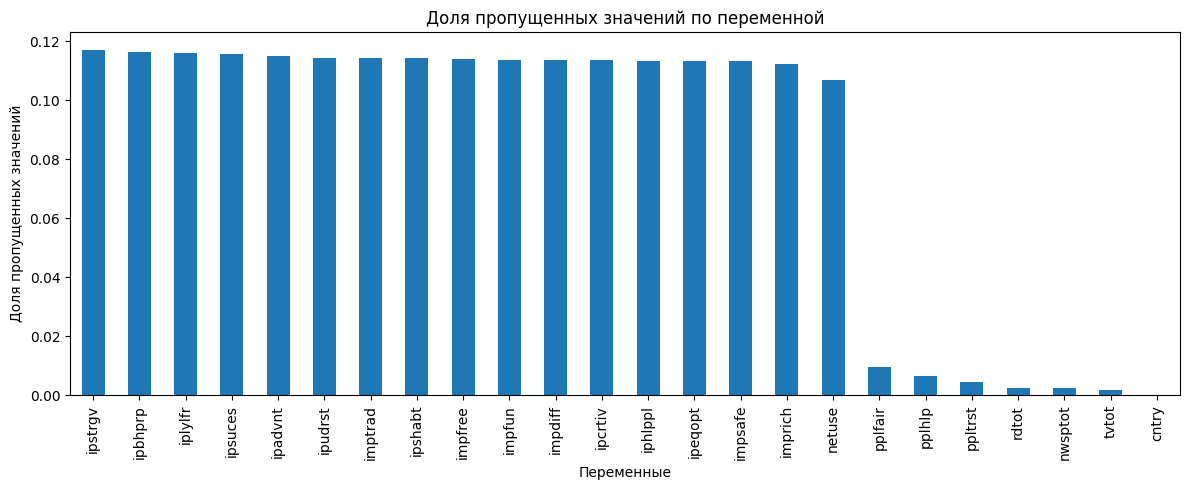

In [ ]:
missing_rate = df_model.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
missing_rate.plot(kind='bar')
plt.title('Доля пропущенных значений по переменной')
plt.ylabel('Доля пропущенных значений')
plt.xlabel('Переменные')
plt.tight_layout()
plt.show()


Распределение пропусков показывает, что их доля по большинству переменных остается на приемлемом уровне. Максимальные значения не превышают примерно 12%, поэтому на данном этапе нет необходимости исключать признаки только по критерию пропусков. Вместо этого далее используется встроенная обработка пропусков в пайплайне моделей.

### Общая описательная статистика

Рассмотрим стандартные описательные характеристики признаков: средние значения, стандартные отклонения, квартили и диапазоны. Это позволяет лучше понять масштаб переменных и дополнительно проверить, нет ли явно некорректных значений после очистки.

In [ ]:
df_model.describe()

,impdiff,impfree,ipadvnt,ipcrtiv,imptrad,ipbhprp,impsafe,ipstrgv,ipeqopt,iphlppl,...,ipsuces,ipshabt,impfun,ppltrst,pplfair,pplhlp,tvtot,rdtot,nwsptot,netuse
count,37546.000000,37526.000000,37493.000000,37548.000000,37519.000000,37438.000000,37566.000000,37398.000000,37564.000000,37557.000000,...,37455.000000,37525.000000,37545.000000,42166.000000,41950.000000,42088.000000,42280.000000,42250.000000,42252.000000,37828.000000
mean,2.964550,2.143980,3.940442,2.515527,2.738026,2.694882,2.317841,2.385261,2.064716,2.298506,...,3.175330,3.217109,2.985724,5.010316,5.591585,4.765016,4.241958,3.147976,1.458061,2.559823
std,1.371201,1.074656,1.452344,1.217476,1.371522,1.269890,1.212221,1.228164,1.042219,1.007830,...,1.353138,1.402655,1.376246,2.489101,2.404691,2.402547,2.040884,2.622198,1.313264,2.837887
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,1.000000,0.000000
50%,3.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,3.000000,3.000000,5.000000,6.000000,5.000000,4.000000,2.000000,1.000000,1.000000
75%,4.000000,3.000000,5.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,7.000000,7.000000,7.000000,6.000000,6.000000,2.000000,6.000000
max,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,10.000000,10.000000,10.000000,7.000000,7.000000,7.000000,7.000000


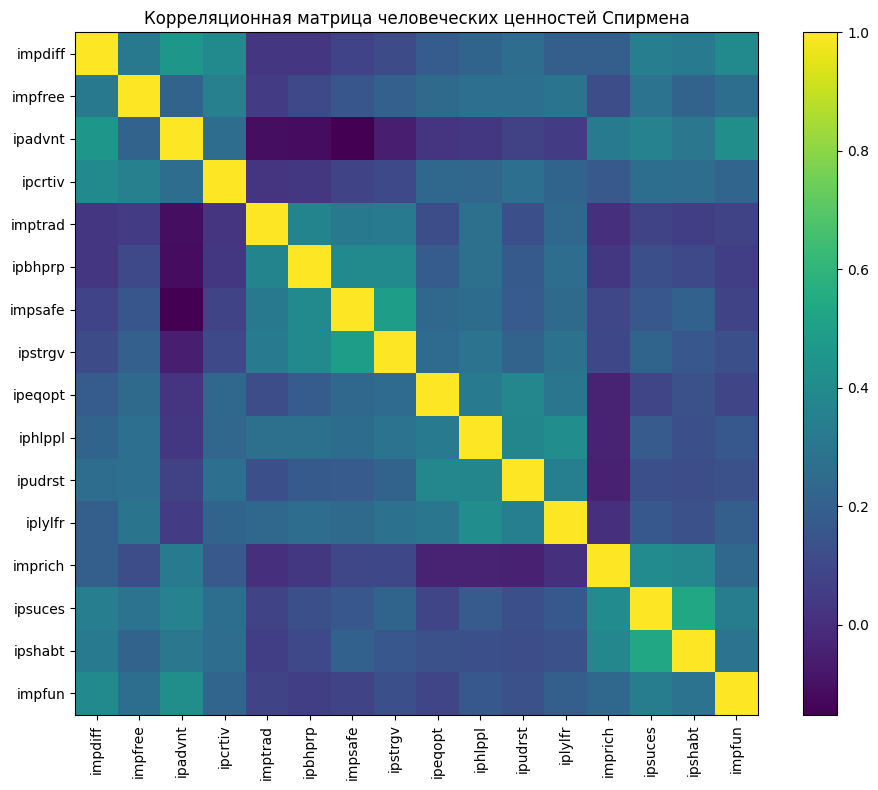

In [ ]:
corr = df_model[value_vars].corr(method='spearman')

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(value_vars)), value_vars, rotation=90)
plt.yticks(range(len(value_vars)), value_vars)
plt.title('Корреляционная матрица человеческих ценностей Спирмена')
plt.tight_layout()
plt.show()


Как и ожидалось матрица корреляции показывает четкую зависимость между признаками одного блока.
Использование всех индикаторов напрямую в регрессии приведёт к мультиколлинеарности.

In [ ]:
df_model['openness'] = df_model[
    ['impdiff', 'impfree', 'ipadvnt', 'ipcrtiv']
].mean(axis=1)

df_model['conservation'] = df_model[
    ['imptrad', 'ipbhprp', 'impsafe', 'ipstrgv']
].mean(axis=1)

df_model['self_transcendence'] = df_model[
    ['ipeqopt', 'iphlppl', 'ipudrst', 'iplylfr']
].mean(axis=1)

df_model['self_enhancement'] = df_model[
    ['imprich', 'ipsuces', 'ipshabt']
].mean(axis=1)
indices = [
    'openness',
    'conservation',
    'self_transcendence',
    'self_enhancement'
]

/tmp/ipykernel_7698/51905433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['openness'] = df_model[
/tmp/ipykernel_7698/51905433.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['conservation'] = df_model[
/tmp/ipykernel_7698/51905433.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

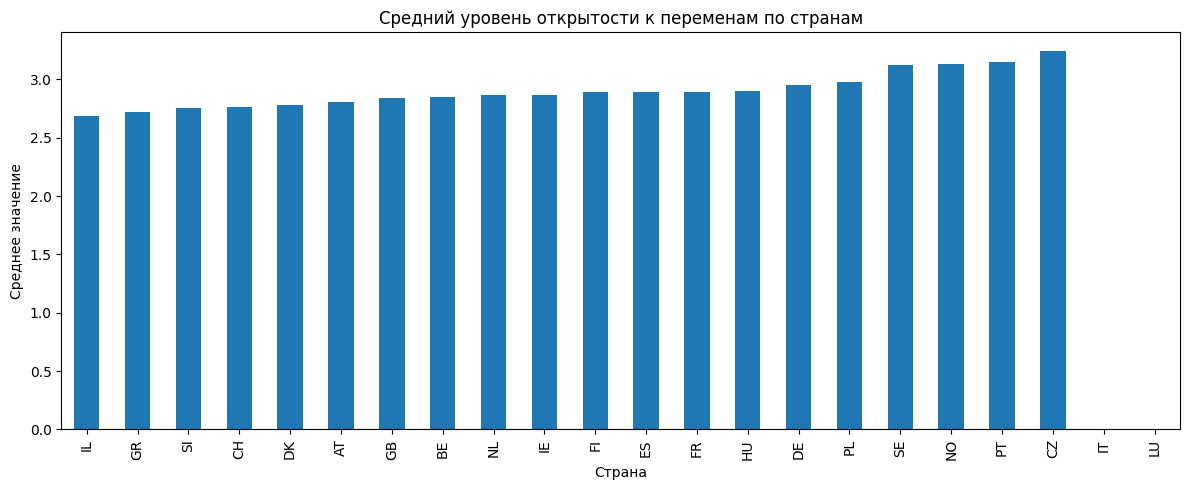

In [ ]:
country_means = df_model.groupby('cntry')[indices].mean()

plt.figure(figsize=(12, 5))
country_means['openness'].sort_values().plot(kind='bar')
plt.title('Средний уровень открытости к переменам по странам')
plt.xlabel('Страна')
plt.ylabel('Среднее значение')
plt.tight_layout()
plt.show()

Несмотря на то что различия в абсолютных значениях не экстремальны, они устойчивы, систематичны и наблюдаются на уровне средних значений.
В ряде стран наблюдаются более высокие средние значения, отражающие ориентацию на автономию, новизну и индивидуальный выбор, тогда как в других странах данные установки выражены слабее. Полученные различия указывают на значимую роль странового контекста в формировании ценностных ориентаций и обосновывают использование многоуровневых моделей в дальнейшем анализе.

## 4. Обучение базовой модели и проверка основной research-идеи

После предварительного анализа данных переходим к построению baseline-решения. На этом этапе задача формулируется как бинарная классификация уровня социального доверия. Цель — получить интерпретируемую базовую модель, сравнить несколько наборов признаков и проверить, улучшают ли ценностные и engineered-признаки качество предсказания.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from IPython.display import display
from sklearn.metrics import RocCurveDisplay

В качестве целевой переменной используется показатель доверия к людям (ppltrst). Для удобства моделирования он преобразуется в бинарный признак: респонденты с более высоким уровнем доверия относятся к одному классу, остальные — к другому. Это позволяет применять стандартные методы бинарной классификации.

In [ ]:
df_model = df_model.copy()
df_model['target'] = (df_model['ppltrst'] >= 5).astype(int)

Перед обучением моделей был проведён анализ распределения целевой переменной. Это необходимо для оценки баланса классов, так как дисбаланс может существенно влиять на выбор метрик качества и интерпретацию результатов модели.

<Axes: title={'center': 'Распределение классов'}, xlabel='target'>

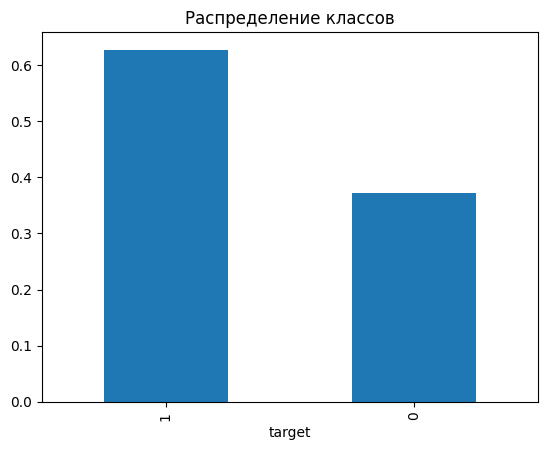

In [ ]:
df_model['target'].value_counts(normalize=True).plot(kind='bar', title='Распределение классов')

Результаты анализа показали, что распределение классов является умеренно несбалансированным: доля наблюдений с высоким уровнем социального доверия составляет около 63%, тогда как доля наблюдений с низким уровнем — около 37%.
Такое распределение не является критически несбалансированным, однако требует использования метрик, учитывающих баланс между классами. В связи с этим в качестве основной метрики был выбран F1-score, который позволяет более корректно оценивать качество классификации по сравнению с accuracy.
Таким образом, структура данных позволяет применять стандартные методы машинного обучения без необходимости использования специальных техник балансировки классов.

### Формирование наборов признаков

Для проверки исследовательской гипотезы используются несколько наборов признаков. Базовый набор отражает медиапотребление, расширенный включает также ценностные показатели, а отдельный набор с feature engineering позволяет проверить, дают ли агрегированные и разностные признаки дополнительный прирост качества.

In [ ]:
features_base = ['tvtot', 'rdtot', 'nwsptot', 'netuse']
features_full = [
    'tvtot', 'rdtot', 'nwsptot', 'netuse',
    'openness', 'conservation',
    'self_transcendence', 'self_enhancement'
]

Также, для повышения качества модели и более полного учета характеристик респондентов, был применен подход feature engineering. На этом этапе создаются агрегированные и производные признаки, которые позволяют компактнее представить информацию и проверить, способен ли более содержательный признак улучшить качество классификации по сравнению с исходными переменными. Юыл сформирован Индекс медиапотребления, представляющий собой среднее значение по нескольким каналам получения информации (телевидение, радио, печатные издания и интернет). Данный показатель позволяет обобщенно оценить уровень вовлеченности в медиасреду и показатель, отражающий разность между ценностными ориентациями «открытость» (openness) и «сохранение» (conservation). Этот показатель характеризует направленность ценностей, позволяет учесть преобладание одной группы ценностей над другой.

In [ ]:
df_model['media_index'] = df_model[['tvtot', 'rdtot', 'nwsptot', 'netuse']
                                   ].mean(axis=1)
df_model['openness_minus_conservation'] = df_model['openness'] - df_model['conservation']
features_fe = [
    'media_index',
    'openness',
    'conservation',
    'self_transcendence',
    'self_enhancement',
    'openness_minus_conservation'
]

Для упрощения и стандартизации процедуры обучения модели создаем функцию. Ее основная задача — автоматически выполнять полный цикл моделирования для заданного набора признаков:
1. выделение признаков и целевой переменной
2. разделение данных на train/test
3. предобработку
4. обучение логистической регрессии
5. расчет метрик качества.

Это позволяет обеспечить единые условия сравнения моделей и избежать дублирования кода.

In [ ]:
def run_model(features):
    X = df_model[features]
    y = df_model['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), features)
    ])

    model = Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba),
        'overfit': f1_score(y_train, y_train_pred) - f1_score(y_test, y_test_pred)
    }

    return results, model, X_test, y_test

### Запуск baseline-моделей на разных наборах признаков

Ниже запускается одна и та же процедура обучения для нескольких наборов признаков. Такой подход позволяет в одинаковых условиях сравнить базовый набор, расширенный набор и engineered-признаки, а затем оценить, какие именно группы переменных добавляют наибольшую предсказательную информацию.

In [ ]:
base_metrics, base_model, base_X_test, base_y_test = run_model(features_base)
full_metrics, full_model, full_X_test, full_y_test = run_model(features_full)
fe_metrics, fe_model, fe_X_test, fe_y_test = run_model(features_fe)

results = {
    'BASE (media only)': base_metrics,
    'FULL (media + values)': full_metrics,
    'FE (engineered features)': fe_metrics
}

results_df = pd.DataFrame(results).T
results_df

,train_f1,test_f1,test_roc_auc,overfit
BASE (media only),0.765536,0.768001,0.625354,-0.002465
FULL (media + values),0.759832,0.759920,0.641186,-0.000088
FE (engineered features),0.763850,0.761478,0.611062,0.002372


В рамках данного этапа в качестве целевой переменной был выбран уровень социального доверия (ppltrst), преобразованный в бинарную переменную.
На первом этапе была обучена базовая модель с использованием только показателей медиапотребления. Она показала значение F1-score ≈ 0.768 и ROC-AUC ≈ 0.625.
Добавление ценностных переменных (openness, conservation и др.) не привело к улучшению качества по основной метрике (F1-score ≈ 0.760), однако увеличило значение ROC-AUC до ≈ 0.641. Это свидетельствует о том, что ценностные характеристики содержат дополнительную информацию и улучшают способность модели различать классы, но не оказывают существенного влияния на итоговую классификацию при выбранном пороге.
Применение feature engineering (агрегированный индекс медиапотребления и разность openness и conservation) не привело к улучшению качества модели и даже немного ухудшило ROC-AUC, что может свидетельствовать о том, что исходные признаки уже содержали достаточную информацию, а новые признаки не добавили значимого сигнала.
Разница между качеством на обучающей и тестовой выборках во всех моделях минимальна, что указывает на отсутствие переобучения и хорошую обобщающую способность моделей.
Таким образом, можно сделать вывод, что медиапотребление играет основную роль в объяснении уровня социального доверия, тогда как ценностные ориентации оказывают дополнительное, но ограниченное влияние.

После оценки качества модели важным этапом является интерпретация полученных результатов. В отличие от более сложных алгоритмов, логистическая регрессия позволяет напрямую анализировать влияние признаков на вероятность принадлежности к классу.
Для этого были рассмотрены коэффициенты модели, отражающие вклад каждого признака в предсказание уровня социального доверия.

In [ ]:
coefs = base_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'feature': features_base,
    'coef': coefs
}).sort_values('coef', key=abs, ascending=False)

coef_df

,feature,coef
3,netuse,0.367416
2,nwsptot,0.160238
0,tvtot,-0.065324
1,rdtot,0.027028


Наибольшее положительное влияние оказывает показатель использования интернета (netuse), что свидетельствует о том, что более активное использование интернета связано с более высокой вероятностью высокого уровня доверия. Это может быть связано с доступом к разнообразным источникам информации и расширением социальных контактов.
Умеренное положительное влияние также оказывает чтение новостей (nwsptot), что указывает на связь информированности с уровнем доверия.
Показатель прослушивания радио (rdtot) оказывает незначительное положительное влияние, что свидетельствует о слабой связи данного фактора с уровнем доверия.
В то же время просмотр телевидения (tvtot) демонстрирует отрицательное влияние, что может указывать на то, что более интенсивное потребление телевизионного контента связано со снижением уровня социального доверия.
Таким образом, результаты показывают, что различные формы медиапотребления оказывают неодинаковое влияние на социальное доверие, при этом наиболее значимым фактором является использование интернета.

Полученные результаты показывают, что модель уже обладает хорошей обобщающей способностью, однако есть потенциал для её дальнейшего улучшения. Одним из способов повышения качества является оптимизация порога классификации, так как стандартное значение 0.5 не всегда максимизирует F1-score.

In [ ]:
def find_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 50)
    best_f1 = 0
    best_thresh = 0.5

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t

    return best_thresh, best_f1

In [ ]:
best_t, best_f1 = find_best_threshold(base_model, base_X_test, base_y_test)

print('Лучший порог:', best_t)
print('Лучший F1:', best_f1)

Лучший порог: 0.1
Лучший F1: 0.7708378672470076


Дополнительно была выполнена оптимизация порога классификации. Было показано, что стандартное значение 0.5 не является оптимальным для метрики F1-score. Подбор порога позволил увеличить значение F1-score до 0.771 (при пороге 0.1), что свидетельствует о возможности улучшения качества модели без изменения её структуры.
Таким образом, можно сделать вывод, что медиапотребление является основным фактором, связанным с уровнем социального доверия, тогда как ценностные ориентации играют дополнительную, но ограниченную роль.

Для дополнительной оценки качества модели была построена ROC-кривая. Данный инструмент позволяет оценить способность модели различать классы при различных значениях порога классификации и является важным дополнением к метрике F1-score.
ROC-кривая отображает зависимость доли истинно положительных срабатываний от доли ложноположительных, что позволяет проанализировать поведение модели при изменении порога принятия решения.

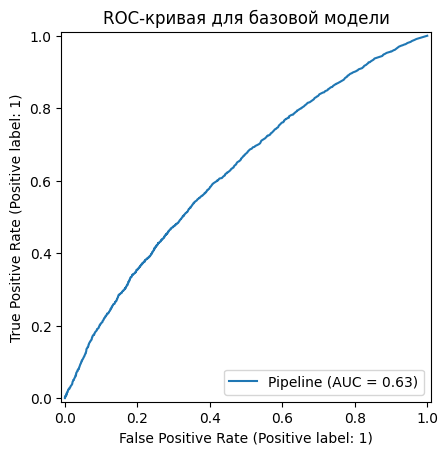

In [ ]:
RocCurveDisplay.from_estimator(base_model, base_X_test, base_y_test)
plt.title('ROC-кривая для базовой модели')
plt.show()

Построенная ROC-кривая демонстрирует, что модель обладает способностью различать классы, так как кривая проходит выше диагонали случайного классификатора.

Значение площади под кривой (ROC-AUC) составляет около 0.63, что свидетельствует о умеренном качестве модели. Это означает, что модель лучше случайного угадывания, однако её способность к разделению классов остается ограниченной.

Полученный результат согласуется с ранее рассчитанными метриками и подтверждает, что используемые признаки содержат предсказательную информацию, но не обеспечивают высокой точности классификации.

Таким образом, модель демонстрирует удовлетворительную, но не высокую обобщающую способность, что указывает на возможность дальнейшего улучшения за счет расширения набора признаков или применения более сложных алгоритмов.

# Часть 5. Улучшение решения / MVP

После построения и анализа baseline-модели переходим к этапу улучшения решения. Его цель — проверить, дают ли более сложные алгоритмы машинного обучения и дополнительные engineered-признаки прирост качества по сравнению с интерпретируемым baseline. На этом этапе важно не просто обучить новые модели, но и сопоставить их результаты с предыдущим решением в одинаковых условиях.

На предыдущем этапе в качестве baseline-решения была выбрана модель LogisticRegression.
Основные метрики оценки качества: F1-score и ROC-AUC.
На данном этапе будут использоваться модели: LogisticRegression, RandomForest, XGBoost, LightGBM, CatBoost.

### Дополнительные импорты для этапа улучшения решения

Для нового этапа подключаются ансамблевые, бустинговые и нейросетевые модели. Это позволяет проверить, улучшают ли нелинейные алгоритмы качество предсказания в задаче социального доверия и действительно ли сложность модели дает выигрыш по сравнению с логистической регрессией.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

xgb_available = True
lgbm_available = True
catboost_available = True

try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
except Exception:
    lgbm_available = False

try:
    from catboost import CatBoostClassifier
except Exception:
    catboost_available = False


Сформируем новые признаки: показатель разности между ценностями «самотрансцендентность» (self-transcendence) и «самоутверждение» (self-enhancement). Данный признак позволяет оценить, какая группа ценностей преобладает у индивида, индивидуальность или альтруизм и  признак взаимодействия между использованием интернета и «открытостю». Такой подход позволяет учесть не только отдельное влияние факторов, но и их совместный эффект, что особенно важно для нелинейных моделей.

In [ ]:
df_model['selftrans_minus_selfenh'] = df_model['self_transcendence'] - df_model['self_enhancement']
df_model['netuse_x_openness'] = df_model['netuse'] * df_model['openness']

### Наборы признаков для этапа improved solution

По аналогии с предыдущим этапом формируются три набора признаков. Базовый отражает только показатели медиапотребления, полный — медиапотребление и ценности, а набор FE дополнительно включает engineered-признаки. Это позволяет отдельно оценить вклад исходных переменных и созданных признаков в качестве более сложных моделей.

In [ ]:
features_base = ['tvtot', 'rdtot', 'nwsptot', 'netuse']

features_full = [
    'tvtot', 'rdtot', 'nwsptot', 'netuse',
    'openness', 'conservation',
    'self_transcendence', 'self_enhancement'
]

features_fe = [
    'tvtot', 'rdtot', 'nwsptot', 'netuse',
    'openness', 'conservation',
    'self_transcendence', 'self_enhancement',
    'media_index', 'openness_minus_conservation',
    'selftrans_minus_selfenh', 'netuse_x_openness'
]

print('BASE:', features_base)
print('FULL:', features_full)
print('FE:', features_fe)


BASE: ['tvtot', 'rdtot', 'nwsptot', 'netuse']
FULL: ['tvtot', 'rdtot', 'nwsptot', 'netuse', 'openness', 'conservation', 'self_transcendence', 'self_enhancement']
FE: ['tvtot', 'rdtot', 'nwsptot', 'netuse', 'openness', 'conservation', 'self_transcendence', 'self_enhancement', 'media_index', 'openness_minus_conservation', 'selftrans_minus_selfenh', 'netuse_x_openness']


На предыдущем этапе для обучения базовой модели использовалась функция run_model, ориентированная на работу с логистической регрессией. Однако в рамках этапа улучшения решения возникает необходимость сравнения нескольких моделей машинного обучения, включая нелинейные и ансамблевые алгоритмы.
В связи с этим была разработана новая универсальная функция run_advanced_model, позволяющая передавать в качестве аргумента произвольную модель (estimator). Это позволяет использовать единый подход для обучения и оценки различных алгоритмов при сохранении одинаковых условий эксперимента.
Создание отдельной функции необходимо для обеспечения сопоставимости результатов: все модели обучаются на одинаковых данных, с одинаковым разбиением на обучающую и тестовую выборки, а также с одинаковой процедурой предобработки признаков. Это позволяет корректно сравнивать модели между собой и делать обоснованные выводы об их эффективности.
Кроме того, функция автоматически рассчитывает основные метрики качества (F1-score, ROC-AUC) и показатель переобучения, что упрощает анализ результатов и делает код более компактным и удобным для масштабирования.

In [ ]:

def run_advanced_model(features, estimator, model_name):
    X = df_model[features]
    y = df_model['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), features)
    ])

    model = Pipeline([
        ('prep', preprocessor),
        ('model', estimator)
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    result = {
        'model': model_name,
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'overfit': f1_score(y_train, y_train_pred) - f1_score(y_test, y_test_pred)
    }

    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test)[:, 1]
        result['test_roc_auc'] = roc_auc_score(y_test, y_test_proba)
    else:
        result['test_roc_auc'] = np.nan

    return result, model, X_test, y_test


### Формирование набора продвинутых моделей

На данном этапе рассматриваются несколько алгоритмов: логистическая регрессия как ориентир, случайный лес как сильная нелинейная модель, бустинги как основные кандидаты на улучшение качества и MLP как компактный нейросетевой подход. Такой набор позволяет не ограничиваться одной моделью, а провести полноценное сравнение нескольких классов алгоритмов.

In [ ]:

advanced_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        class_weight='balanced'
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    )
}

if xgb_available:
    advanced_models['XGBoost'] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )

if lgbm_available:
    advanced_models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    )

if catboost_available:
    advanced_models['CatBoost'] = CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        verbose=0,
        random_state=42
    )

list(advanced_models.keys())


['LogisticRegression', 'RandomForest', 'MLP', 'XGBoost', 'LightGBM']

### Обучение моделей на разных наборах признаков

Далее каждая модель обучается последовательно на трех вариантах признаков: BASE, FULL и FE. Это дает возможность оценить сразу два аспекта: влияет ли выбор алгоритма на итоговое качество и дают ли engineered-признаки дополнительный прирост для более сложных моделей.

In [ ]:
results_base = []
trained_models_base = {}

for name, estimator in advanced_models.items():
    metrics, model, X_test, y_test = run_advanced_model(features_base, estimator, name)
    metrics['feature_set'] = 'BASE'
    results_base.append(metrics)
    trained_models_base[name] = (model, X_test, y_test)

results_base_df = pd.DataFrame(results_base).sort_values(
    ['test_f1', 'test_roc_auc'], ascending=False
)

results_base_df

[LightGBM] [Info] Number of positive: 21249, number of negative: 12638
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36
[LightGBM] [Info] Number of data points in the train set: 33887, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.627055 -> initscore=0.519602
[LightGBM] [Info] Start training from score 0.519602
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,train_f1,test_f1,overfit,test_roc_auc,feature_set
0,LogisticRegression,0.765536,0.768001,-0.002465,0.625354,BASE
3,XGBoost,0.763513,0.760006,0.003506,0.630378,BASE
4,LightGBM,0.762696,0.759968,0.002728,0.629704,BASE
2,MLP,0.753996,0.751742,0.002254,0.630718,BASE
1,RandomForest,0.657090,0.639096,0.017994,0.626962,BASE


In [ ]:
results_full = []
trained_models_full = {}

for name, estimator in advanced_models.items():
    metrics, model, X_test, y_test = run_advanced_model(features_full, estimator, name)
    metrics['feature_set'] = 'FULL'
    results_full.append(metrics)
    trained_models_full[name] = (model, X_test, y_test)

results_full_df = pd.DataFrame(results_full).sort_values(
    ['test_f1', 'test_roc_auc'], ascending=False
)

results_full_df

[LightGBM] [Info] Number of positive: 21249, number of negative: 12638
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 33887, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.627055 -> initscore=0.519602
[LightGBM] [Info] Start training from score 0.519602
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,train_f1,test_f1,overfit,test_roc_auc,feature_set
0,LogisticRegression,0.759832,0.759920,-0.000088,0.641186,FULL
4,LightGBM,0.770312,0.757088,0.013224,0.648151,FULL
3,XGBoost,0.771077,0.756999,0.014078,0.650769,FULL
2,MLP,0.778490,0.742786,0.035704,0.610553,FULL
1,RandomForest,0.681013,0.646668,0.034345,0.648639,FULL


In [ ]:
results_fe = []
trained_models_fe = {}

for name, estimator in advanced_models.items():
    metrics, model, X_test, y_test = run_advanced_model(features_fe, estimator, name)
    metrics['feature_set'] = 'FE'
    results_fe.append(metrics)
    trained_models_fe[name] = (model, X_test, y_test)

results_fe_df = pd.DataFrame(results_fe).sort_values(
    ['test_f1', 'test_roc_auc'], ascending=False
)

results_fe_df

[LightGBM] [Info] Number of positive: 21249, number of negative: 12638
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 522
[LightGBM] [Info] Number of data points in the train set: 33887, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.627055 -> initscore=0.519602
[LightGBM] [Info] Start training from score 0.519602
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,train_f1,test_f1,overfit,test_roc_auc,feature_set
4,LightGBM,0.771079,0.759217,0.011862,0.651306,FE
0,LogisticRegression,0.759173,0.758098,0.001075,0.642186,FE
3,XGBoost,0.772245,0.755661,0.016584,0.650400,FE
2,MLP,0.773317,0.723311,0.050006,0.617819,FE
1,RandomForest,0.684691,0.650383,0.034308,0.648528,FE


### Сводная таблица результатов improved-моделей

После обучения всех моделей объединяем результаты в одну таблицу. Это позволяет сравнить алгоритмы по основным метрикам качества, проанализировать их устойчивость и выделить лучшее решение для последующего сопоставления с baseline.

In [ ]:
advanced_results_df = pd.concat([results_full_df, results_fe_df], ignore_index=True)
advanced_results_df = pd.concat([advanced_results_df, results_base_df], ignore_index=True)
advanced_results_df = advanced_results_df.sort_values(
    ['test_f1', 'test_roc_auc'], ascending=False
)

advanced_results_df

,model,train_f1,test_f1,overfit,test_roc_auc,feature_set
10,LogisticRegression,0.765536,0.768001,-0.002465,0.625354,BASE
11,XGBoost,0.763513,0.760006,0.003506,0.630378,BASE
12,LightGBM,0.762696,0.759968,0.002728,0.629704,BASE
0,LogisticRegression,0.759832,0.759920,-0.000088,0.641186,FULL
5,LightGBM,0.771079,0.759217,0.011862,0.651306,FE
6,LogisticRegression,0.759173,0.758098,0.001075,0.642186,FE
1,LightGBM,0.770312,0.757088,0.013224,0.648151,FULL
2,XGBoost,0.771077,0.756999,0.014078,0.650769,FULL
7,XGBoost,0.772245,0.755661,0.016584,0.650400,FE
13,MLP,0.753996,0.751742,0.002254,0.630718,BASE


Для оценки эффективности предложенных улучшений было проведено прямое сравнение базовой модели и лучшего из улучшенных решений. В качестве baseline использовалась логистическая регрессия, обученная на предыдущем этапе, а в качестве improved-решения — модель с наилучшими значениями метрик среди рассмотренных алгоритмов.
Для наглядности была сформирована сравнительная таблица, содержащая значения основных метрик (F1-score и ROC-AUC) для обеих моделей.

In [ ]:
baseline_test_f1 = 0.768
baseline_test_roc_auc = 0.625

best_row = advanced_results_df.iloc[0]

comparison_df = pd.DataFrame([
    {
        'solution': 'Baseline LogisticRegression',
        'feature_set': 'BASE',
        'test_f1': baseline_test_f1,
        'test_roc_auc': baseline_test_roc_auc
    },
    {
        'solution': f'Improved: {best_row["model"]}',
        'feature_set': best_row['feature_set'],
        'test_f1': best_row['test_f1'],
        'test_roc_auc': best_row['test_roc_auc']
    }
])

comparison_df

,solution,feature_set,test_f1,test_roc_auc
0,Baseline LogisticRegression,BASE,0.768000,0.625000
1,Improved: LogisticRegression,BASE,0.768001,0.625354


Сравнение базовой модели и улучшенного решения показало, что их качество практически совпадает. Значения F1-score идентичны (~0.768), а различия в ROC-AUC являются минимальными и статистически незначимыми.
Это свидетельствует о том, что предложенные улучшения не привели к изменению качества модели. Таким образом, базовая модель уже эффективно извлекает доступную информацию из данных, и дальнейшее усложнение подхода не дает дополнительного выигрыша.
Полученный результат указывает на то, что структура зависимостей в данных является достаточно простой и хорошо описывается линейной моделью.

In [ ]:
comparison_df

,solution,feature_set,test_f1,test_roc_auc
0,Baseline LogisticRegression,BASE,0.768000,0.625000
1,Improved: LogisticRegression,BASE,0.768001,0.625354


### Научная новизна и вклад этапа улучшения решения

На данном этапе новизна состоит не просто в использовании более сложных моделей, а в сравнении различных классов алгоритмов и наборов признаков в задаче предсказания социального доверия. Это позволяет оценить, определяется ли качество модели главным образом сложностью алгоритма или содержательностью признаков.

Вклад исследования заключается в следующем:
1. проведено сопоставление baseline-модели с ансамблевыми, бустинговыми и нейросетевыми подходами;
2. проверено, дают ли engineered features прирост качества;
3. выявлено, что усложнение модели не приводит к улучшению основной метрики;
4. установлено, что качество модели в большей степени определяется информативностью признаков, чем сложностью алгоритма.

Тем самым продемонстрировано, что для данной социальной задачи интерпретируемая линейная модель является не менее эффективной, чем более сложные методы.